# **Проект спринта 14. Нелинейные модели против южной погоды**

## Цели и задачи
### Цель:
Разработать модель, которая будет предсказывать, сколько велосипедов потребуется в каждый конкретный час, исходя из погодных и календарных условий.

Для компании важно:

1. Повысить точность прогнозов.
2. Оптимизировать логистику распределения велосипедов.
3. Улучшить клиентский опыт, избегая простоев и дефицита.

Модель должна улучшить точность прогнозирования по отношению к действующей системе, использующей линейную регрессию.

### Задачи:
1. Загрузка обучающей и тестовой выборок.
2. Загрузка существующей модели, которая будет использоваться как базовая, и проверка ее на тестовой выборке.
3. Подсчет метрик RMSE, MAE, $R^2$ базовой модели.
4. Исследовательский анализ данных.
5. Предобработка данных для машинного обучения.
6. Обучение моделей регрессии kNN и дерева решений, получение оценок на кросс-валидации с параметрами по умолчанию.
7. Подбор гиперпараметров моделей регрессии при помощи библиотеки Optuna.
8. Оценка моделей с лучшими гиперпараметрами на кросс-валидации и их сравнение с обученными ранее моделями, а также с базовой моделью.
9. Добавление новых признаков с использованием кастомного трансформера. Оценка результатов.

### Постановка задачи в терминах машинного обучения
- Тип задачи машинного обучения: обучение с учителем, регрессия.
- Целевая переменная - числовая, почасовой спрос на аренду велосипедов (см. `Rented Bike Count`).
- Модели машинного обучения - kNN и решающие деревья.
- Необходимо использовать кросс-валидацию для оценки качества моделей.
- Основные метрики - RMSE, MAE, $R^2$. 
- Для подбора оптимального набора гиперпараметров следует использовать байесовскую оптимизацию.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.

### Описание данных

Представлены два датасета, для обучения и тестирования, в формате CSV. Оба датасета имеют одну структуру:
| **Признак**                     | **Описание**                                                                                                                                                                                                                                                                                  | **Единица измерения**                                                                                                                                                                                                |
| ------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `Temperature`                   | Температура воздуха в градусах Цельсия (°C).                                                                                                                                                                                                                                                  | Градус Цельсия, °C.                                                                                                                                                                                                  |
| `Humidity`                      | Относительная влажность воздуха.                                                                                                                                                                                                                                                              | Процент водяного пара в воздухе.                                                                                                                                                                                     |
| `Windspeed`                     | Скорость ветра.                                                                                                                                                                                                                                                                               | Метр в секунду.                                                                                                                                                                                                      |
| `Visibility`                    | Видимость (в десятках метров).                                                                                                                                                                                                                                                                | Десять метров.                                                                                                                                                                                                       |
| `Dew Point Temperature`         | Точка росы (°C).                                                                                                                                                                                                                                                                              | Градус Цельсия, °C.                                                                                                                                                                                                  |
| `Solar Radiation`               | Солнечная радиация (MJ/m²).                                                                                                                                                                                                                                                                   | Мегаджоуль на квадратный метр, МДж/м², или MJ/m².                                                                                                                                                                    |
| `Rainfall`                      | Количество осадков (мм).                                                                                                                                                                                                                                                                      | Миллиметр, мм.                                                                                                                                                                                                       |
| `Snowfall`                      | Количество снега (см).                                                                                                                                                                                                                                                                        | Сантиметр, см.                                                                                                                                                                                                       |
| `Seasons`                       | Времена года: `Winter`, `Spring`, `Summer`, `Autumn`.                                                                                                                                                                                                                                         | `Winter` — зима, `Spring` — весна, `Summer` — лето, `Autumn` — осень.                                                                                                                                                |
| `Holiday`                       | Был ли в этот день выходной или праздничный день.                                                                                                                                                                                                                                             | `Holiday` — выходной или праздник, `No Holiday` — будний день.                                                                                                                                                       |
| `Functioning Day`               | Были ли велосипеды арендованы в рабочее время.                                                                                                                                                                                                                                                | `Yes` — да, функциональные часы, `No` — нет, техническое обслуживание станций проката.                                                                                                                               |
| Несколько колонок `Time_Period` | Каждая запись в датасете относится к одному из пяти временных периодов:  <br>  <br>**•** `Night` — c 00:00 по 05:59;  <br>**•** `Morning` — с 06:00 по 09:59.  <br>**•** `Daytime` — с 10:00 по 15:59.  <br>**•** `Evening` — с 16:00 по 19:59;  <br>**•** `Late Evening` — с 20:00 по 23:59. | `True` и `False`.  <br>  <br>Данные о периоде `Daytime` — это базовое состояние. Запись, у которой в четырёх колонках c временным промежуткам указано значение `False`, автоматически относится к периоду `Daytime`. |
| `Rented Bike Count`               | Количество арендованных велосипедов (целевая переменная).                                                                                                                                                                                                                                                | Арендованные за час велосипеды                                                                                                                               |

### Структура проекта
1. [Подготовка среды и загрузка данных.](#1-подготовка-среды-и-загрузка-данных)
    - 1.1. [Установка библиотек](#11-установка-библиотек)
    - 1.2. [Импорт необходмых библиотек](#12-импорт-необходимых-библиотек)
    - 1.3. [Загрузка данных и базовой модели](#13-загрузка-данных-и-базовой-модели)
2. [Исследовательский анализ данных](#2-исследовательский-анализ-данных)
    - 2.1. [Первоначальный анализ данных - пропуски и дубликаты](#21-первоначальный-анализ---пропуски-и-дубликаты)
    - 2.2. [Исследование категориальных и булевых признаков](#22-исследование-категориальных-и-булевых-признаков)
    - 2.3. [Исследование числовых признаков](#23-исследование-числовых-признаков)
    - 2.4. [Исследование корреляций признаков и целевой переменной](#24-исследование-корреляций-признаков-и-целевой-переменной)
    - 2.5. [Выводы](#25-выводы)
3. [Разработка базовых нелинейных моделей](#3-разработка-базовых-нелинейных-моделей)
    - 3.1. [Пайплайны предобработки](#31-пайплайны-предобработки)
    - 3.2. [Базовые модели `KNeighborsRegressor` и `DecisionTreeRegressor`](#32-базовые-модели-kneighborsregressor-и-decisiontreeregressor)
4. [Подбор гиперпараметров моделей kNN и дерева решений](#4-подбор-гиперпараметров-моделей-knn-и-дерева-решений)
    - 4.1. [Улучшение модели `KNeighborsRegressor`](#41-улучшение-модели-kneighborsregressor)
    - 4.2. [Улучшение модели `DecisionTreeRegressor`](#42-улучшение-модели-decisiontreeregressor)
    - 4.3. [Проверка улучшенных моделей на кросс валидации](#43-проверка-улучшенных-моделей-на-кросс-валидации)
    - 4.4. [Выводы](#44-выводы)
5. [Интерпретация и оценка на тестовой выборке](#5-интерпретация-и-оценка-на-тестовой-выборке)
    - 5.1. [Интерпретация модели `DecisionTreeRegressor`](#51-интерпретация-модели-decisiontreeregressor)
    - 5.2. [Оценка модели на тестовой выборке](#52-оценка-модели-на-тестовой-выборке)
6. [Сохранение пайплайна и финальный отчёт](#6-сохранение-пайплайна-и-финальный-отчёт)
    - 6.1. [Сохранение пайплайна](#61-сохранение-пайплайна)
    - 6.2. [Финальный отчет](#62-финальный-отчет)

## 1. Подготовка среды и загрузка данных

### 1.1. Установка библиотек

In [1]:
%pip install "scikit-learn==1.6.1" "numpy==1.26.4"
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik
%pip install -q optuna
%pip install -q joblib

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1.2. Импорт необходимых библиотек

In [2]:
import os
from urllib.request import urlopen

# Библиотеки для вычислений и работы с датасетами
import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import average_precision_score, r2_score, mean_absolute_percentage_error, \
    mean_absolute_error, root_mean_squared_error, make_scorer
from sklearn.model_selection import cross_validate, cross_val_score, \
    KFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.base import BaseEstimator, TransformerMixin, clone

# Подбор гиперпараметров
import optuna

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.3. Загрузка данных и базовой модели

In [3]:
# Константы и общие настройки
RANDOM_SEED = 42
pd.options.display.float_format = '{:.4f}'.format

BASE_URL = "https://code.s3.yandex.net/"

def load_dataset(file_name):
    try: 
        if os.path.exists(file_name):
            return pd.read_csv(file_name)
        else:
            return pd.read_csv(BASE_URL + file_name)
    except:
        print("Ошибка загрузки датасета")            
        raise

def load_model(file_name):
    try: 
        if os.path.exists(file_name):
            return joblib.load(file_name)
        else:
            with urlopen(BASE_URL + file_name) as response:
                return joblib.load(response)
    except:
        print("Ошибка загрузки модели")            
        raise

df_train = load_dataset("datasets/ds_s14_train_data.csv")
df_test = load_dataset("datasets/ds_s14_test_data.csv")

display(HTML("<h3>Обучающая выборка</h3>"))
display(df_train.info())
display(df_train.head())
display(HTML("<h3>Тестовая выборка</h3>"))
display(df_test.info())
display(df_test.head())

display(HTML("<h3>Базовая модель</h3>"))
base_model = load_model("data-scientist/baseline_linear_regression_pipeline.pkl")
display(base_model)

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

None

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3000,35.0000,2.4000,2000.0000,4.3000,0.4600,0.0000,0.0000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4000,55.0000,3.2000,2000.0000,15.6000,0.1500,0.0000,0.0000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9000,39.0000,1.6000,2000.0000,-18.5000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2000,37.0000,2.2000,2000.0000,-17.6000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4000,34.0000,2.1000,2000.0000,6.6000,2.8400,0.0000,0.0000,Autumn,No Holiday,Yes,False,False,False,False,1686


<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

None

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7000,48.0000,0.8000,817.0000,-3.5000,0.3900,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3000,90.0000,1.1000,311.0000,-6.6000,0.0000,0.0000,2.2000,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9000,66.0000,1.2000,173.0000,-2.8000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1000,63.0000,2.6000,949.0000,15.6000,1.6800,0.0000,0.0000,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3000,43.0000,1.2000,1257.0000,10.0000,1.9100,0.0000,0.0000,Summer,No Holiday,Yes,False,False,True,False,1005


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('str_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('ohe_pass', 'passthrough',
                                                  ['Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Morning',
                                                   'Time_Period_Night'])])),
                ('regressor', LinearRegression())])

- Датасеты и модель загружены успешно.
- Набор признаков и целевая переменная соответствую описанию.
- Структура обучающей и тестовой выборок совпадают.

## 2. Работа с базовой моделью

- Запустим предсказание на обучающей и тестовой выборках и посчитаем метрики RMSE, MAE, $R^2$:

In [4]:
# Функция для расчета метрик
def calc_metrics(y_test, y_pred, decimals=4):
    return pd.Series([round(r2_score(y_test, y_pred), decimals),
                      round(mean_absolute_error(y_test, y_pred), decimals),
                      round(root_mean_squared_error(y_test, y_pred), decimals)],
                      index=["R2", "MAE", "RMSE"])

X_test = df_test.drop(columns=['Rented Bike Count'])
y_test = df_test['Rented Bike Count']

X_train = df_train.drop(columns=['Rented Bike Count'])
y_train = df_train['Rented Bike Count']

# Предсказание на обучающей выборке
y_pred_train = base_model.predict(X_train)

# Предсказание на тестовой выборке
y_pred_test = base_model.predict(X_test)

display(HTML("<b>Метрики на обучающей выборке:</b>"))
display(calc_metrics(y_train, y_pred_train))
display(HTML("<b>Метрики на тестовой выборке:</b>"))
display(calc_metrics(y_test, y_pred_test))

R2       0.5925
MAE    309.0784
RMSE   412.5264
dtype: float64

R2       0.5861
MAE    312.5993
RMSE   411.5641
dtype: float64

### Выводы:
- Качество предсказаний модели неудовлетворительно. Модель объясняет 59% дисперсии целевой переменной и ошибается в среднем на 312 велосипедов в час.

## 2. Исследовательский анализ данных

### 2.1. Сведения о датасете и преобразование названий 
- Выведем сведения о датасете:

In [5]:
display(df_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

None

- Типы числовых столбцов определены верно.
- Столбцы `Holiday` и `Functioning Day` имеют тип `str`, однако хранят значения булевых типов. Их можно преобразовать в тип `bool` или закодировать при помощи `OneHotEncoder`, как и категориальные.
- Столбцы `Time_Period_*` для исследовательского анализа данных лучше преобразовать в один категориальный столбец.

- Описание функций для построения диаграмм:

In [6]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, xlabel, ylabel, hue=None, stat='count', figsize=(12, 6), bins='auto', kde=True, **kwargs):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel(xlabel)  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat,
                **kwargs)

    # ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_in_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_histogram_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 3))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_histogram_in_grid(
                df,
                key,
                value['title'] if 'title' in value else key, 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 **kwargs):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        **kwargs)
    
    # kwargs['ax'].legend(bbox_to_anchor=(1, 1))
    
    if mean != None:
        if vertical:
            kwargs['ax'].axhline(mean, color='red', linestyle='--')
        else:
            kwargs['ax'].axvline(mean, color='red', linestyle='--')   

def show_barplot_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 5))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_barplot_grid(
                value['data'],
                value['title'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                value.get('rot'),
                value['vertical'] if 'vertical' in value else True,
                value.get('mean'),
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_in_grid(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_scatterplot_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_scatterplot_in_grid(
                df,
                key[0],
                key[1],
                value['title'] if 'title' in value else "/".join(key), 
                value['xlabel'] if 'xlabel' in value else key[0], 
                value['ylabel'] if 'ylabel' in value else key[1], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

### 2.1. Первоначальный анализ - пропуски и дубликаты
- Проанализируем обучающий датасет на наличие пропусков и дубликатов

In [7]:
# Посчитаем количество строк с пропусками
misses = df_train.isna().sum(axis=1).sum()
display(HTML(f"<b>Количество строк с пропусками: </b>{misses} ({misses / len(df_train) * 100:.2f}%)"))

display(HTML(f"<b>Количество дубликатов: </b>{df_train.drop(columns=['Rented Bike Count']).duplicated().sum()}"))

- Явных дубликатов не найдено.
- Строк с пропусками в разных признаках более 20%, пропуски необходимо заполнять.

- Разделим признаки на числовые и категориальные;
- Соберем булевы признаки времени дня в один категориальный для удобства анализа при помощи кастомного трансформера.
- Строковые признаки `Holiday` и `Functioning Day` преобразуем в булевы.

In [8]:
class BikeSouthTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.day_periods = ['Time_Period_Morning',
                            'Time_Period_Evening',
                            'Time_Period_Late Evening',
                            'Time_Period_Night']
    
    def fit(self, X, y=None):
        self.feature_names_out_ = [col for col in X.columns 
                                   if not col in self.day_periods] + ['day_period']
        return self

    def transform(self, X):
        rv = X.copy()
        rv['day_period'] = (rv[self.day_periods]
                            .idxmax(axis=1)
                            .where(rv[self.day_periods].any(axis=1), 'Time_Period_Day'))
        rv['Holiday'] = (rv['Holiday'] == 'Holiday')
        rv['Functioning Day'] = (rv['Functioning Day'] == 'Yes')
        return rv.drop(columns=self.day_periods)
    
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

In [9]:
target = 'Rented Bike Count'
num_features = df_train.drop(columns=[target]).select_dtypes(include='number').columns.to_list()
cat_features = df_train.select_dtypes(include='object').columns.to_list()
day_periods = ['Time_Period_Morning',
                'Time_Period_Evening',
                'Time_Period_Late Evening',
                'Time_Period_Night']
display(HTML("<h2>Числовые признаки: </h2><ul><li>" + "</li><li>".join(num_features) + "</li></ul>"))

display(HTML("<h2>Категориальные признаки до преобразования: </h2><ul><li>" + "</li><li>".join(cat_features) + "</li></ul>"))

day_period_transformer = BikeSouthTransformer()
df_train_pp = day_period_transformer.fit_transform(df_train)

bool_features = df_train_pp.select_dtypes(include='bool').columns.to_list()
cat_features2 = df_train_pp.select_dtypes(include='object').columns.to_list()

display(HTML("<h2>Булевы признаки после преобразования: </h2><ul><li>" + "</li><li>".join(bool_features) + "</li></ul>"))
display(HTML("<h2>Категориальные признаки после преобразования: </h2><ul><li>" + "</li><li>".join(cat_features2) + "</li></ul>"))

display(HTML(f"<b>Пропусков в `day_period`: </b> {df_train_pp['day_period'].isna().sum()}"))

C:\Users\TEXNH MAKPH\AppData\Local\Temp\ipykernel_12184\3624964604.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df_train.select_dtypes(include='object').columns.to_list()


C:\Users\TEXNH MAKPH\AppData\Local\Temp\ipykernel_12184\3624964604.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features2 = df_train_pp.select_dtypes(include='object').columns.to_list()


### 2.2. Исследование категориальных и булевых признаков

- Исследуем распределение целевой переменной в зависимости от категориальных признаков:

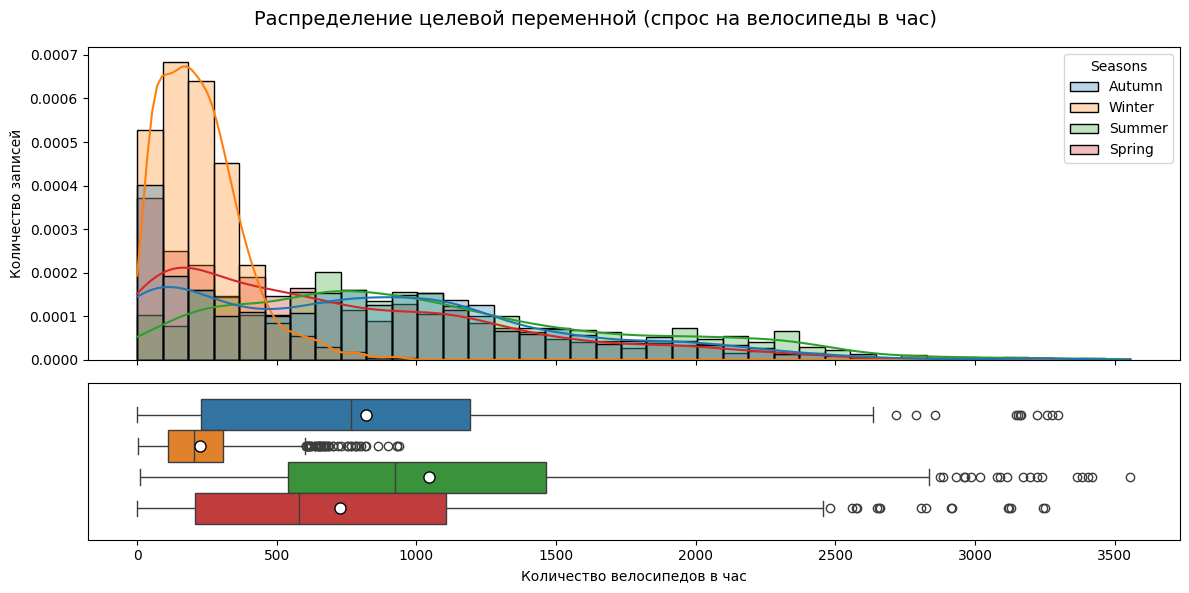

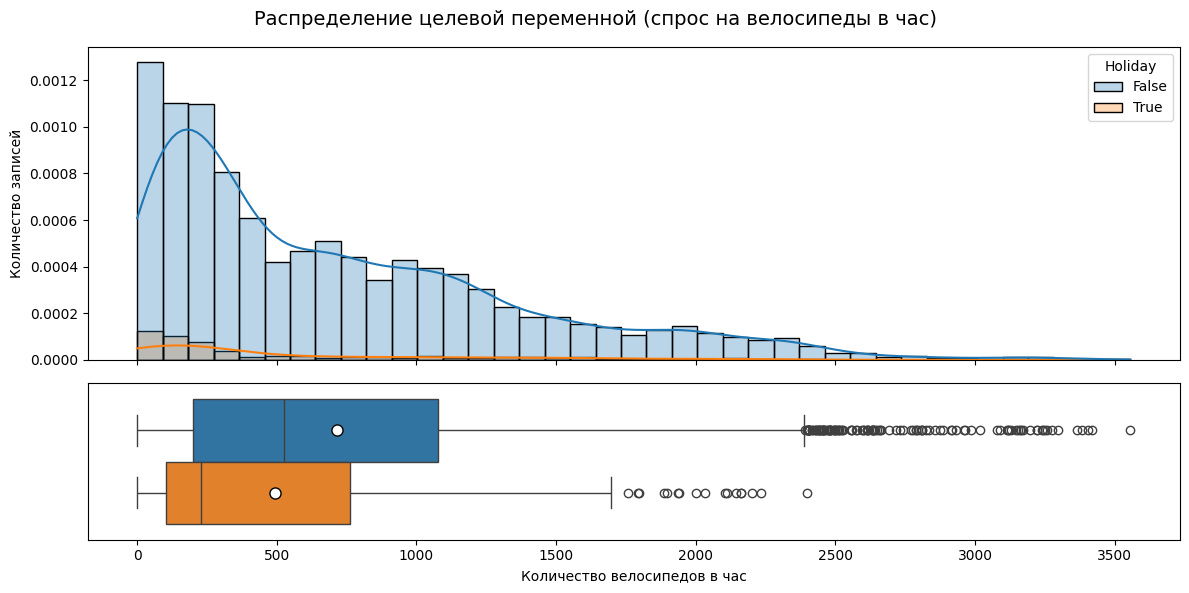

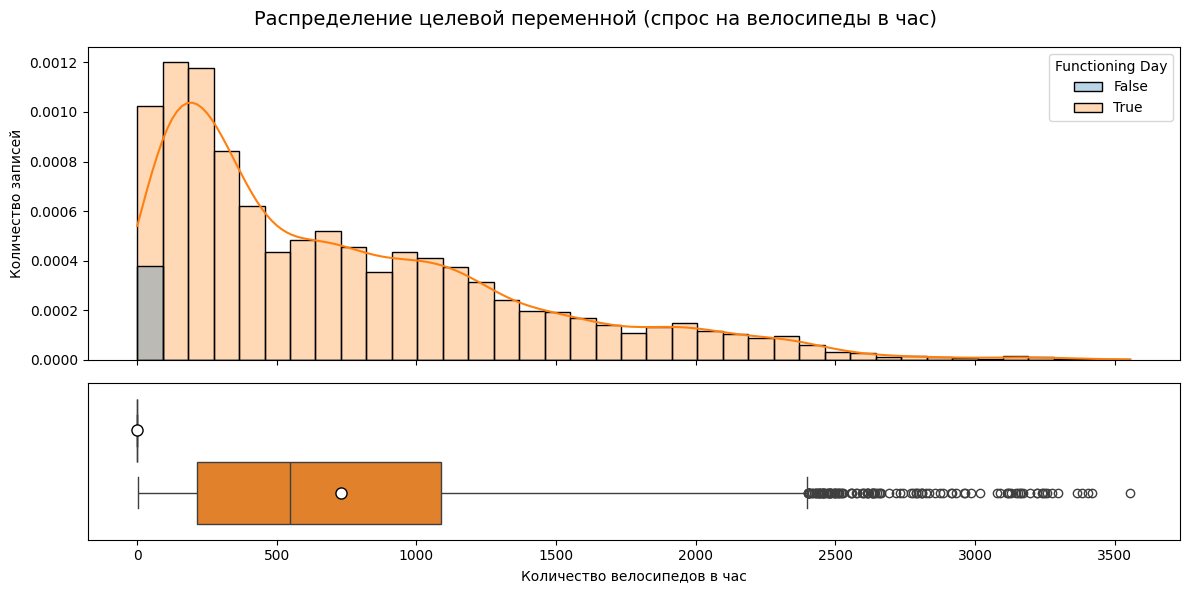

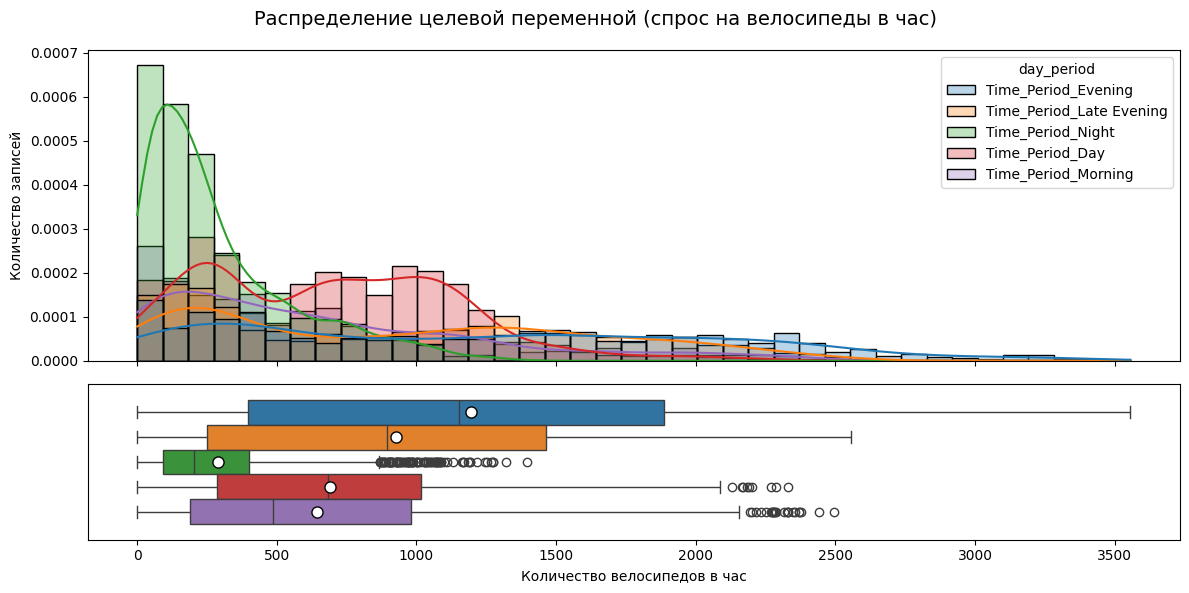

In [10]:
draw_double_diag(df_train_pp,
                 "Распределение целевой переменной (спрос на велосипеды в час)",
                 target,
                 "Количество велосипедов в час",
                 "Количество записей",
                 hue='Seasons',
                 stat='density',
                 alpha=0.3)

draw_double_diag(df_train_pp,
                 "Распределение целевой переменной (спрос на велосипеды в час)",
                 target,
                 "Количество велосипедов в час",
                 "Количество записей",
                 hue='Holiday',
                 stat='density',
                 alpha=0.3)

draw_double_diag(df_train_pp,
                 "Распределение целевой переменной (спрос на велосипеды в час)",
                 target,
                 "Количество велосипедов в час",
                 "Количество записей",
                 hue='Functioning Day',
                 stat='density',
                 alpha=0.3)

draw_double_diag(df_train_pp,
                 "Распределение целевой переменной (спрос на велосипеды в час)",
                 target,
                 "Количество велосипедов в час",
                 "Количество записей",
                 hue='day_period',
                 stat='density',
                 alpha=0.3)

- Видно изменение спроса в зависимости от сезона: наименьший спрос зимой, наибольший - летом и осенью.
- В рабочие дни спрос больше, чем в выходные.
- Присутствует значительная разница в спросе в зависимости от времени дня: наибольший спрос - в вечернее время, наименьший - в ночное.
- Выбросы и аномальные значения отсутствуют.

### 2.3. Исследование числовых признаков

- Исследуем распределение числовых признаков:

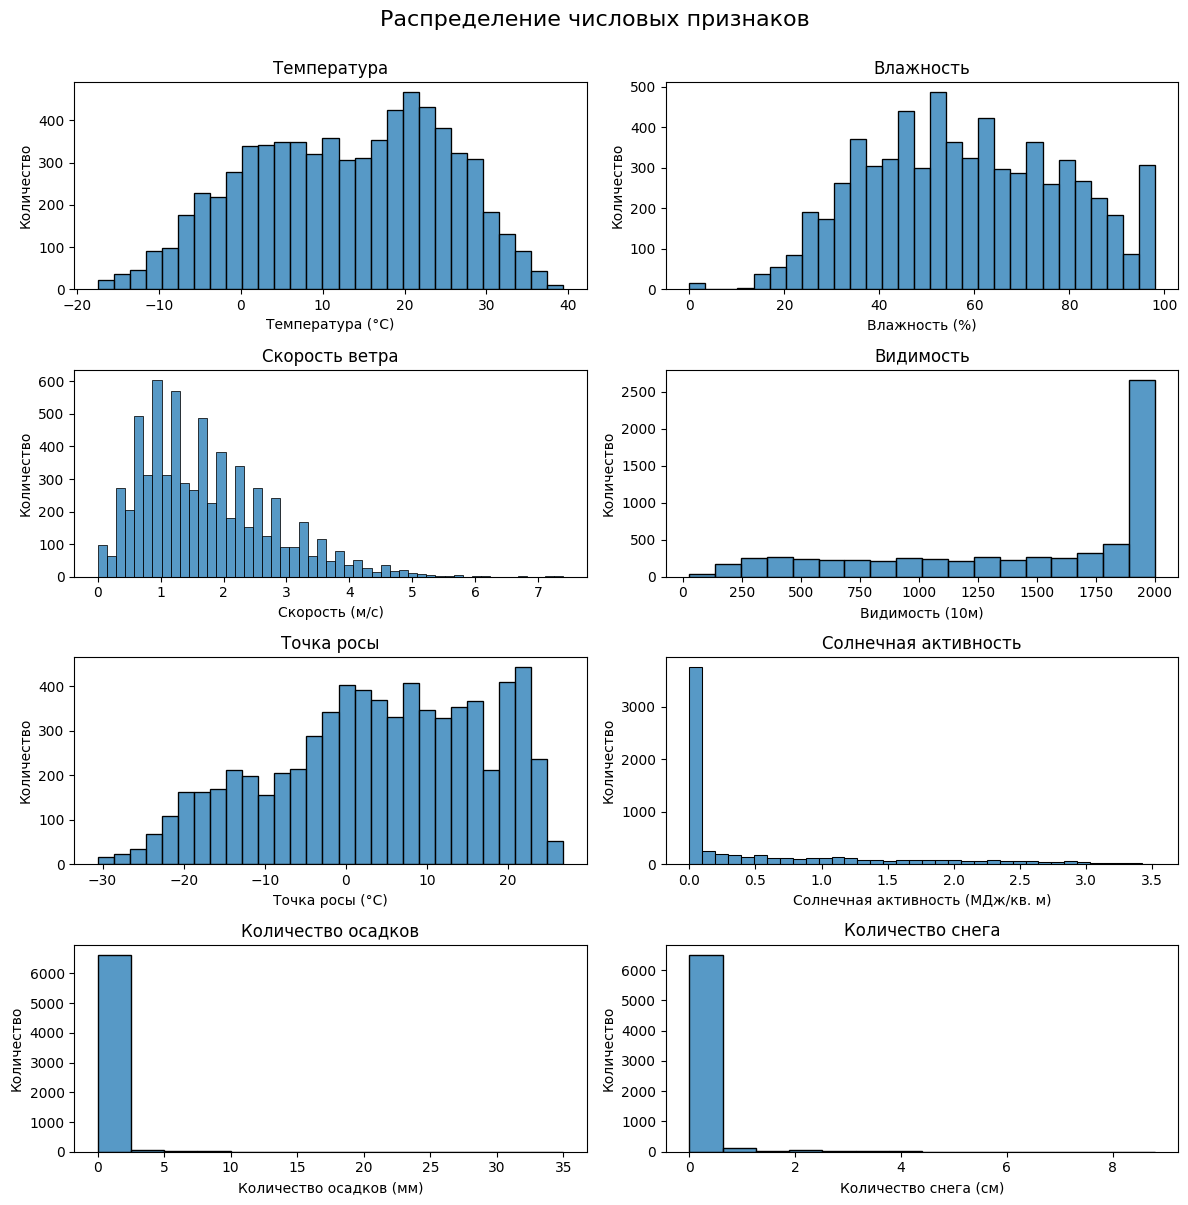

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,7008.0000,6758.0000,6798.0000,6749.0000,7008.0000,6798.0000,6746.0000,6745.0000
mean,12.8129,58.2005,1.7252,1435.1568,4.0215,0.5699,0.1469,0.0748
std,11.9247,20.3403,1.0430,607.2910,13.0334,0.8661,1.1641,0.4382
min,-17.5000,0.0000,0.0000,27.0000,-30.6000,0.0000,0.0000,0.0000
25%,3.3000,42.0000,0.9000,936.0000,-4.7000,0.0000,0.0000,0.0000
50%,13.5000,57.0000,1.5000,1691.0000,5.0000,0.0100,0.0000,0.0000
75%,22.4000,74.0000,2.3000,2000.0000,14.8000,0.9400,0.0000,0.0000
max,39.4000,98.0000,7.4000,2000.0000,26.8000,3.5200,35.0000,8.8000


In [11]:
num_features_desc = {
    'Temperature': {'title': "Температура", 'xlabel': "Температура (°C)"},
    'Humidity(%)': {'title': "Влажность", 'xlabel': "Влажность (%)"},
    'Wind speed (m/s)': {'title': "Скорость ветра", 'xlabel': "Скорость (м/с)"},
    'Visibility (10m)': {'title': "Видимость", 'xlabel': "Видимость (10м)"},
    'Dew point temperature': {'title': "Точка росы", 'xlabel': "Точка росы (°C)"},
    'Solar Radiation (MJ/m2)': {'title': "Солнечная активность", 'xlabel': "Солнечная активность (МДж/кв. м)"},
    'Rainfall(mm)': {'title': "Количество осадков", 'xlabel': "Количество осадков (мм)"},
    'Snowfall (cm)':  {'title': "Количество снега", 'xlabel': "Количество снега (см)"}
}

show_histogram_grid(df_train_pp, num_features_desc, "Распределение числовых признаков")
display(df_train_pp[num_features].describe())

- Выбросы и аномальные значения в числовых переменных отсутствуют, значения погодных параметров соответствуют южным регионам.

- Построим скаттерплоты целевой переменной и числовых признаков:

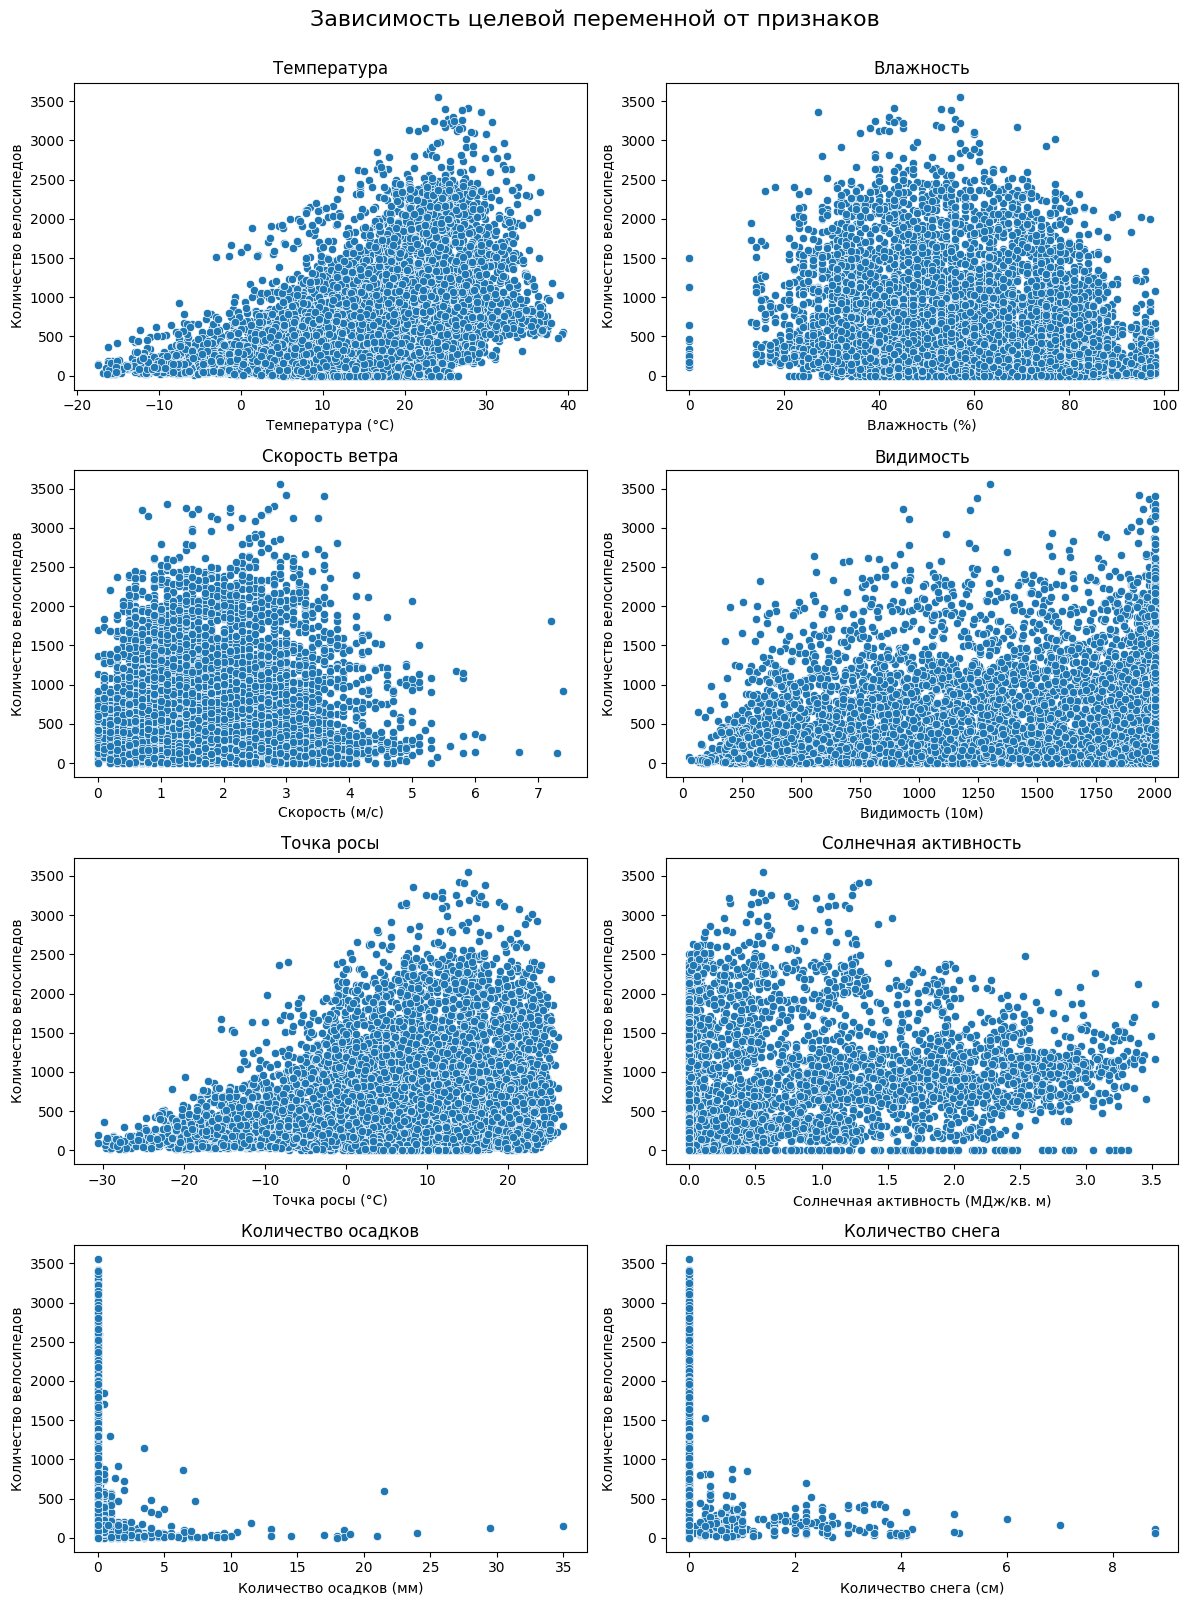

In [12]:
scatterplot_desc = {
    ('Temperature', target): {'title': "Температура", 'xlabel': "Температура (°C)", 'ylabel': "Количество велосипедов"},
    ('Humidity(%)', target): {'title': "Влажность", 'xlabel': "Влажность (%)", 'ylabel': "Количество велосипедов"},
    ('Wind speed (m/s)', target): {'title': "Скорость ветра", 'xlabel': "Скорость (м/с)", 'ylabel': "Количество велосипедов"},
    ('Visibility (10m)', target): {'title': "Видимость", 'xlabel': "Видимость (10м)", 'ylabel': "Количество велосипедов"},
    ('Dew point temperature', target): {'title': "Точка росы", 'xlabel': "Точка росы (°C)", 'ylabel': "Количество велосипедов"},
    ('Solar Radiation (MJ/m2)', target): {'title': "Солнечная активность", 'xlabel': "Солнечная активность (МДж/кв. м)", 'ylabel': "Количество велосипедов"},
    ('Rainfall(mm)', target): {'title': "Количество осадков", 'xlabel': "Количество осадков (мм)", 'ylabel': "Количество велосипедов"},
    ('Snowfall (cm)', target):  {'title': "Количество снега", 'xlabel': "Количество снега (см)", 'ylabel': "Количество велосипедов"}}

show_scatterplot_grid(df_train_pp, scatterplot_desc, "Зависимость целевой переменной от признаков")

- Видна зависимость целевой переменной от погодных условий - температуры, влажности и солнечной активности. 
- Наибольший спрос наблюдается при температуре около 25 градусов и влажности около 60%
- При сильном ветре, высокой солнечной активности, осадках спрос падает.

### 2.4. Исследование корреляций признаков и целевой переменной
- Построим тепловую карту корреляции признаков между собой и с целевой переменной:

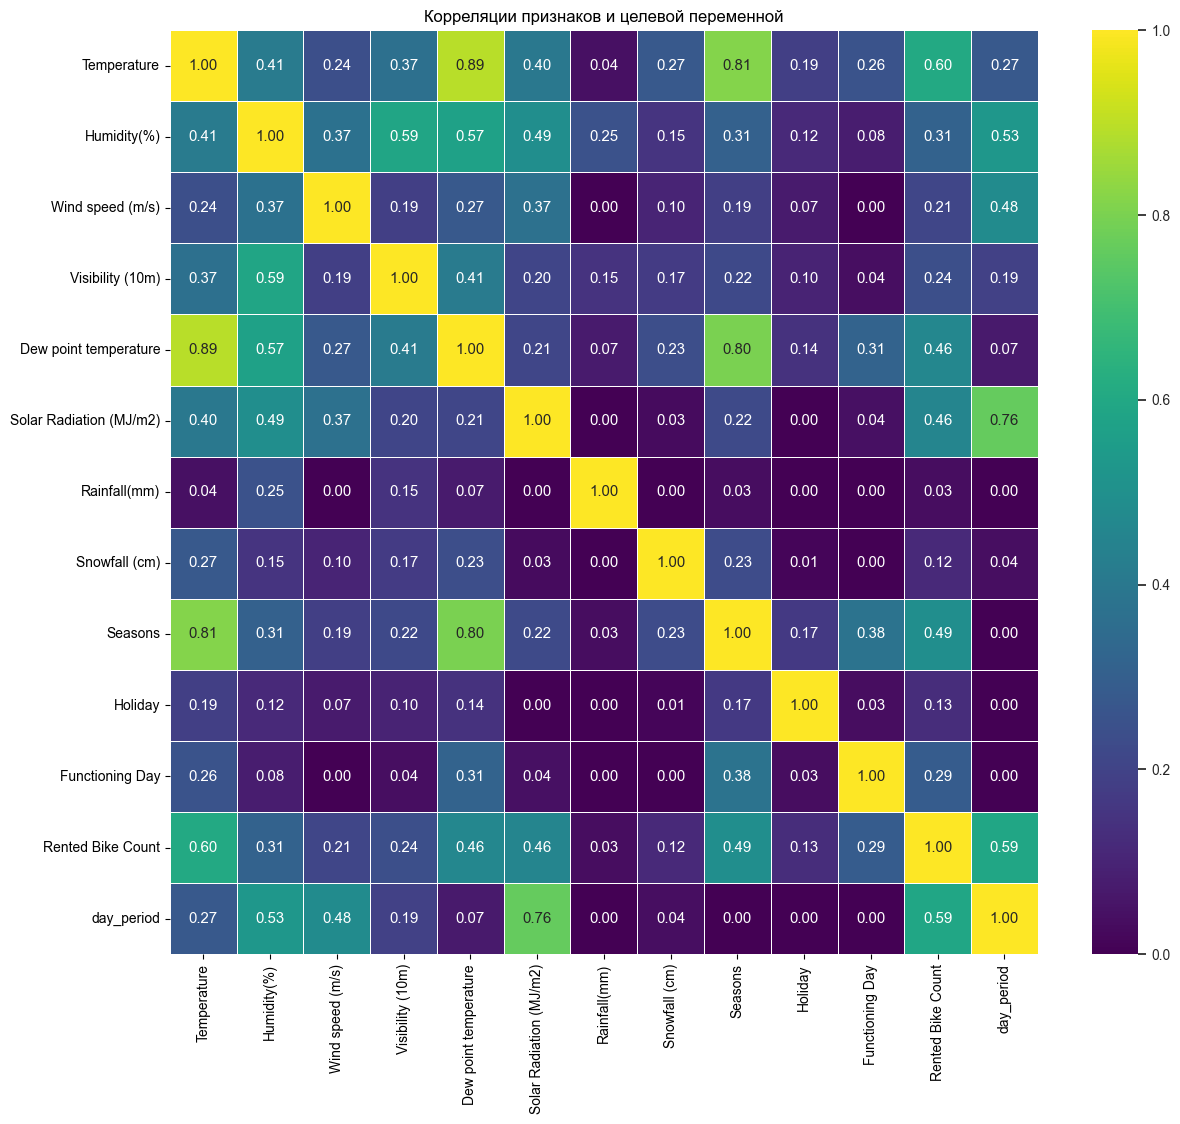

In [13]:
phik_matrix = phik.phik_matrix(df_train_pp, interval_cols=num_features + [target])
draw_heatmap(phik_matrix, "Корреляции признаков и целевой переменной", figsize=(14, 12), font_scale=0.9)

### 2.5. Выводы
- Явных дубликатов в датасете не найдено.
- Строк с пропусками в разных признаках более 20%, пропуски необходимо заполнить медианой.
- Видно изменение спроса в зависимости от сезона: наименьший спрос зимой, наибольший - летом и осенью.
- В рабочие дни спрос больше, чем в выходные.
- Присутствует значительная разница в спросе в зависимости от времени дня: наибольший спрос - в вечернее время, наименьший - в ночное.
- Выбросы и аномальные значения в категориальных и числовых признаках отсутствуют.
- В датасете присутствуют ожидаемо высокие корреляции погодных параметров с сезоном и временем дня.
- Наибольший спрос наблюдается при температуре около 25 градусов и влажности около 60%
- При сильном ветре, высокой солнечной активности, осадках спрос падает.
- Целевая переменная в наибольшей степени коррелирует с периодом дня и температурой. В наименьшей степени - с количеством осадков и флагом выходного дня.

## 3. Разработка базовых нелинейных моделей
- Построим пайплайны для моделей kNN и дерева решений с параметрами по умолчанию и сравним их с предоставленной линейной моделью.
### 3.1. Пайплайны предобработки
- Построим пайплайны предобработки данных для нелинейных моделей. 
- Пайплайн для kNN будет включать масштабирование числовых признаков, а пайплайн для дерева решений будет использовать немасштабированные значения.
- Пропуски в числовых столбцах будут заполняться медианой.
- Категориальные параметры будут закодированы при помощи `OneHotEncoder`.

In [14]:
# Получим обучающую выборку с необходимым набором признаков
X_train_full = df_train[num_features + cat_features + day_periods]
y_train_full = df_train[target]

X_train, X_val, y_train, y_val = X_train_full, X_train_full, y_train_full, y_train_full
# X_train, X_val, y_train, y_val = train_test_split(X_train_full,
#                                                   y_train_full,
#                                                   test_size=0.5,
#                                                   random_state=RANDOM_SEED)

cat_pipeline = Pipeline([
    ('feng', BikeSouthTransformer()),
    ('cat_pp', ColumnTransformer(
        transformers=[('ohe', OneHotEncoder(sparse_output=False), cat_features2)],
        remainder='passthrough'
    ))
])

# Предобработка для kNN
knn_pp = ColumnTransformer(transformers=[
    ('num', Pipeline([
                ('fill_missed', SimpleImputer(strategy='median')),
                ('num_scale', StandardScaler())
            ]), num_features),
    ('cat', clone(cat_pipeline), cat_features + day_periods),
])
knn_pp.set_output(transform='pandas')

# Предобработка для деревьев
tree_pp = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', clone(cat_pipeline), cat_features + day_periods)
])
tree_pp.set_output(transform='pandas');

### 3.2. Базовые модели `KNeighborsRegressor` и `DecisionTreeRegressor`
- Построим пайплайны с моделями регресии, используя параметры по умолчанию:

In [15]:
# Базовый пайплайн для kNN
base_knn_pipeline = Pipeline([
    ('preprocess', clone(knn_pp)),
    ('regressor', KNeighborsRegressor())
])

# Базовый пайплайн для дерева
base_tree_pipeline = Pipeline([
    ('preprocess', clone(tree_pp)),
    ('regressor', DecisionTreeRegressor(random_state=RANDOM_SEED))
])

- Оценим базовые модели на кросс-валидации:

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
base_knn_cv = cross_validate(base_knn_pipeline,
                                  X_train,
                                  y_train,
                                  cv=cv,
                                  scoring=['r2', 'neg_mean_absolute_error', 
                                           'neg_root_mean_squared_error'])

base_knn_cv_filtered = pd.DataFrame(base_knn_cv).filter(regex="train|test")
base_knn_metrics_cv = pd.DataFrame({'Base kNN Mean': base_knn_cv_filtered.abs().mean(), 
                                   'Base kNN Std.Dev.': base_knn_cv_filtered.abs().std()})

display(HTML("<h3>Метрики базовой kNN</h3>"))
display(base_knn_metrics_cv)

base_tree_cv = cross_validate(base_tree_pipeline,
                                  X_train,
                                  y_train,
                                  cv=cv,
                                  scoring=['r2', 'neg_mean_absolute_error', 
                                           'neg_root_mean_squared_error'])

display(HTML("<h3>Метрики базовой DecisionTreeRegressor</h3>"))

base_tree_cv_filtered = pd.DataFrame(base_tree_cv).filter(regex="train|test")
base_tree_metrics_cv = pd.DataFrame({'Base Tree Mean': base_tree_cv_filtered.abs().mean(), 
                                   'Base Tree Std.Dev.': base_tree_cv_filtered.abs().std()})
display(base_tree_metrics_cv)

,Base kNN Mean,Base kNN Std.Dev.
test_r2,0.7294,0.0134
test_neg_mean_absolute_error,223.9869,6.6367
test_neg_root_mean_squared_error,335.9423,6.9204


,Base Tree Mean,Base Tree Std.Dev.
test_r2,0.6102,0.0260
test_neg_mean_absolute_error,249.9612,7.2234
test_neg_root_mean_squared_error,403.2028,15.5554


- Обе базовые модели на кросс-валидации показывают лучшие результаты, чем представленная линейная модель на тестовой выборке.
- Модель `DecisionTreeRegressor` показывает худшие результаты, чем `kNN`; вероятно, она переобучается на фолдах кросс-валидации. Возможно, эту проблему удастся решить подбором гиперпараметров.

## 4. Подбор гиперпараметров моделей `kNN` и дерева решений
### 4.1. Улучшение модели `KNeighborsRegressor`
- Опишем функцию цели для `kNN`:

In [17]:
def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 20),
        'metric': trial.suggest_categorical('metric', ['euclidean',
                                                        'manhattan',
                                                        'minkowski']),
        'p': trial.suggest_int('p', 3, 7),
        'weights': trial.suggest_categorical('weights', ['uniform', 
                                                         'distance'])
    }

    knn_pipeline = Pipeline([
        ('preprocess', clone(knn_pp)),
        ('regressor', KNeighborsRegressor(**params))
    ])

    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=make_scorer(r2_score)
    )

    r2_score_mean = scores.mean()
    trial.report(r2_score_mean, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return r2_score_mean

- Запустим эксперимент:

In [18]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

study_knn = optuna.create_study(direction="maximize", sampler=sampler) 
study_knn.optimize(objective_knn, n_trials=30, show_progress_bar=True) 

display(HTML("<b>Наилучшие гиперпараметры:</b> " + str(study_knn.best_params)))
display(HTML(f"<b>Лучшая R2: </b>{study_knn.best_value:4f}"))

[I 2026-05-23 12:55:22,288] A new study created in memory with name: no-name-899033a3-5e41-4a4f-a87d-9c9c21134929
Best trial: 0. Best value: 0.730773:   3%|▎         | 1/30 [00:00<00:07,  3.77it/s]

[I 2026-05-23 12:55:22,548] Trial 0 finished with value: 0.7307725143017015 and parameters: {'n_neighbors': 9, 'metric': 'euclidean', 'p': 3, 'weights': 'uniform'}. Best is trial 0 with value: 0.7307725143017015.


Best trial: 0. Best value: 0.730773:   7%|▋         | 2/30 [00:00<00:07,  3.88it/s]

[I 2026-05-23 12:55:22,803] Trial 1 finished with value: 0.7306162281315564 and parameters: {'n_neighbors': 18, 'metric': 'manhattan', 'p': 7, 'weights': 'uniform'}. Best is trial 0 with value: 0.7307725143017015.


Best trial: 2. Best value: 0.736838:  10%|█         | 3/30 [00:01<00:13,  1.98it/s]

...

[I 2026-05-23 12:55:30,700] Trial 27 finished with value: 0.7529976881176841 and parameters: {'n_neighbors': 5, 'metric': 'manhattan', 'p': 5, 'weights': 'distance'}. Best is trial 17 with value: 0.7554930256922525.


Best trial: 17. Best value: 0.755493:  97%|█████████▋| 29/30 [00:09<00:00,  2.55it/s]

[I 2026-05-23 12:55:31,529] Trial 28 pruned. 


Best trial: 17. Best value: 0.755493: 100%|██████████| 30/30 [00:09<00:00,  3.18it/s]

[I 2026-05-23 12:55:31,721] Trial 29 pruned. 


### 4.2. Улучшение модели `DecisionTreeRegressor`
- Опишем функцию цели для `DecisionTreeRegressor`:

In [19]:
def objective_tree(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 20, 100),
        'criterion': trial.suggest_categorical('criterion', ['squared_error',
                                                            'absolute_error'])
    }

    tree_pipeline = Pipeline([
        ('preprocess', clone(tree_pp)),
        ('regressor', DecisionTreeRegressor(random_state=RANDOM_SEED, **params))
    ])

    scores = cross_val_score(
        tree_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=make_scorer(r2_score)
    )

    r2_score_mean = scores.mean()
    trial.report(r2_score_mean, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return r2_score_mean

- Запустим эксперимент:

In [20]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

study_tree = optuna.create_study(direction="maximize", sampler=sampler) 
study_tree.optimize(objective_tree, n_trials=30, show_progress_bar=True) 

display(HTML("<b>Наилучшие гиперпараметры:</b> " + str(study_tree.best_params)))
display(HTML(f"<b>Лучшая R2: </b>{study_tree.best_value:4f}"))

[I 2026-05-23 12:55:31,748] A new study created in memory with name: no-name-2578ccdc-8b73-4a0f-a953-5caf485a182e
Best trial: 0. Best value: 0.748618:   3%|▎         | 1/30 [00:00<00:04,  6.15it/s]

[I 2026-05-23 12:55:31,913] Trial 0 finished with value: 0.7486184551581352 and parameters: {'max_depth': 9, 'min_samples_split': 48, 'min_samples_leaf': 15, 'max_leaf_nodes': 68, 'criterion': 'squared_error'}. Best is trial 0 with value: 0.7486184551581352.


Best trial: 0. Best value: 0.748618:   7%|▋         | 2/30 [00:02<00:44,  1.59s/it]

[I 2026-05-23 12:55:34,496] Trial 1 finished with value: 0.5415799368307294 and parameters: {'max_depth': 4, 'min_samples_split': 44, 'min_samples_leaf': 13, 'max_leaf_nodes': 77, 'criterion': 'absolute_error'}. Best is trial 0 with value: 0.7486184551581352.


Best trial: 0. Best value: 0.748618:  10%|█         | 3/30 [00:05<01:01,  2.27s/it]

...

[I 2026-05-23 12:55:51,931] Trial 25 pruned. 
[I 2026-05-23 12:55:52,081] Trial 26 finished with value: 0.7526674592884849 and parameters: {'max_depth': 18, 'min_samples_split': 31, 'min_samples_leaf': 4, 'max_leaf_nodes': 87, 'criterion': 'squared_error'}. Best is trial 4 with value: 0.753586041915072.


Best trial: 28. Best value: 0.757242:  97%|█████████▋| 29/30 [00:20<00:00,  6.48it/s]

[I 2026-05-23 12:55:52,247] Trial 27 pruned. 
[I 2026-05-23 12:55:52,397] Trial 28 finished with value: 0.7572420815600965 and parameters: {'max_depth': 16, 'min_samples_split': 50, 'min_samples_leaf': 4, 'max_leaf_nodes': 75, 'criterion': 'squared_error'}. Best is trial 28 with value: 0.7572420815600965.


Best trial: 29. Best value: 0.758992: 100%|██████████| 30/30 [00:20<00:00,  1.44it/s]

[I 2026-05-23 12:55:52,543] Trial 29 finished with value: 0.7589918105447729 and parameters: {'max_depth': 10, 'min_samples_split': 49, 'min_samples_leaf': 6, 'max_leaf_nodes': 70, 'criterion': 'squared_error'}. Best is trial 29 with value: 0.7589918105447729.


### 4.3. Проверка улучшенных моделей на кросс-валидации
- Получим оценки на кросс-валидации модели `kNN`:

In [21]:
final_knn_pipeline = Pipeline([
    ('preprocess', clone(knn_pp)),
    ('regressor', KNeighborsRegressor(**study_knn.best_params))
])

final_knn_cv = cross_validate(
    final_knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=['r2', 'neg_mean_absolute_error', 
                'neg_root_mean_squared_error']
)

final_knn_cv_filtered = pd.DataFrame(final_knn_cv).filter(regex="train|test")
final_knn_metrics_cv = pd.DataFrame({'kNN Mean': final_knn_cv_filtered.abs().mean(), 
                                   'kNN Std.Dev.': final_knn_cv_filtered.abs().std()})

display(final_knn_metrics_cv)

,kNN Mean,kNN Std.Dev.
test_r2,0.7555,0.0139
test_neg_mean_absolute_error,213.3204,7.3243
test_neg_root_mean_squared_error,319.3328,9.0258


- Получим оценки на кросс-валидации модели `DecisionTreeRegressor`:

In [22]:
final_tree_pipeline = Pipeline([
    ('preprocess', clone(tree_pp)),
    ('regressor', DecisionTreeRegressor(**study_tree.best_params))
])

final_tree_cv = cross_validate(
    final_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=['r2', 'neg_mean_absolute_error', 
                'neg_root_mean_squared_error']
)
final_tree_cv_filtered = pd.DataFrame(final_tree_cv).filter(regex="train|test")

final_tree_metrics_cv = pd.DataFrame({'Tree Mean': final_tree_cv_filtered.abs().mean(), 
                                   'Tree Std.Dev': final_tree_cv_filtered.abs().std()})
display(final_tree_metrics_cv)

,Tree Mean,Tree Std.Dev
test_r2,0.7590,0.0161
test_neg_mean_absolute_error,215.4119,8.2670
test_neg_root_mean_squared_error,316.9827,10.4799


- Для корректного сравнения получим аналогичные метрики предоставленной базовой модели:

In [23]:
base_cv = cross_validate(
    FrozenEstimator(base_model),
    X_train,
    y_train,
    cv=5,
    scoring=['r2', 'neg_mean_absolute_error', 
                'neg_root_mean_squared_error']
)
base_cv_filtered = pd.DataFrame(base_cv).filter(regex="train|test")

base_metrics_cv = pd.DataFrame({'Base Mean': base_cv_filtered.abs().mean(), 
                                   'Base Std.Dev': base_cv_filtered.abs().std()})

display(base_metrics_cv)

,Base Mean,Base Std.Dev
test_r2,0.5923,0.0146
test_neg_mean_absolute_error,309.0786,7.1359
test_neg_root_mean_squared_error,412.4062,11.1648


- Объединим метрики моделей в одну таблицу и отобразим их на диаграмме:

,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error
Base Mean,0.5923,309.0786,412.4062
Base Std.Dev,0.0146,7.1359,11.1648
Base kNN Mean,0.7294,223.9869,335.9423
Base kNN Std.Dev.,0.0134,6.6367,6.9204
Base Tree Mean,0.6102,249.9612,403.2028
Base Tree Std.Dev.,0.0260,7.2234,15.5554
kNN Mean,0.7555,213.3204,319.3328
kNN Std.Dev.,0.0139,7.3243,9.0258
Tree Mean,0.7590,215.4119,316.9827
Tree Std.Dev,0.0161,8.2670,10.4799


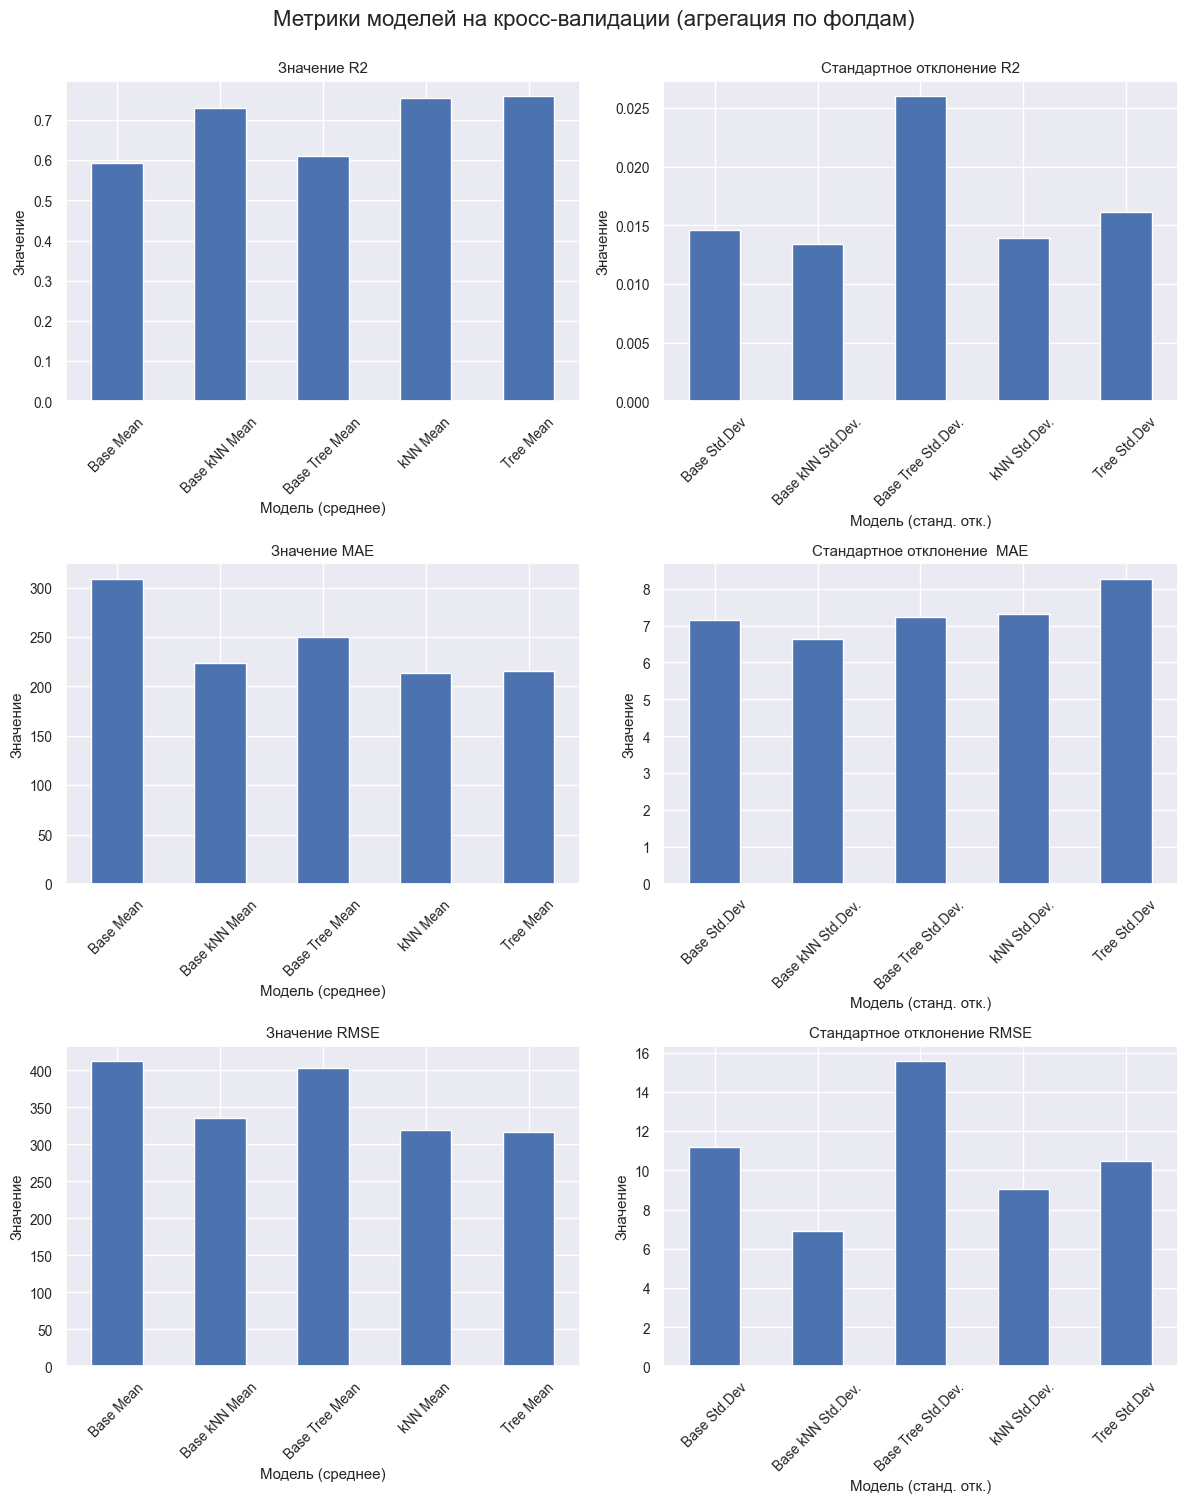

In [24]:
metrics_summary = pd.concat([base_metrics_cv, 
                             base_knn_metrics_cv, 
                             base_tree_metrics_cv, 
                             final_knn_metrics_cv, 
                             final_tree_metrics_cv], axis=1).T
display(metrics_summary)
barplot_desc = [
    {"data": (metrics_summary['test_r2']
              .filter(regex=".*Mean")),
     "title": "Значение R2", "xlabel": "Модель (среднее)", "ylabel": "Значение", "rot": 45},
    {"data": (metrics_summary['test_r2']
              .filter(regex=".*Std.Dev")),
     "title": "Стандартное отклонение R2", "xlabel": "Модель (станд. отк.)", "ylabel": "Значение", "rot": 45},
    {"data": (metrics_summary['test_neg_mean_absolute_error']
              .filter(regex=".*Mean")),
     "title": "Значение MAE", "xlabel": "Модель (среднее)", "ylabel": "Значение", "rot": 45},
    {"data": (metrics_summary['test_neg_mean_absolute_error']
              .filter(regex=".*Std.Dev")),
     "title": "Стандартное отклонение  MAE", "xlabel": "Модель (станд. отк.)", "ylabel": "Значение", "rot": 45},
    {"data": (metrics_summary['test_neg_root_mean_squared_error']
              .filter(regex=".*Mean")),
     "title": "Значение RMSE", "xlabel": "Модель (среднее)", "ylabel": "Значение", "rot": 45},
    {"data": (metrics_summary['test_neg_root_mean_squared_error']
              .filter(regex=".*Std.Dev")),
     "title": "Стандартное отклонение RMSE", "xlabel": "Модель (станд. отк.)", "ylabel": "Значение", "rot": 45}
     
]

show_barplot_grid(barplot_desc, "Метрики моделей на кросс-валидации (агрегация по фолдам)")



### 4.4 Выводы
- kNN и решающее дерево показывают лучшие результаты по всем метрикам, чем предоставленная линейная модель.
- Решающее дерево с гиперпараметрами по умолчанию показывает худшие результаты, чем kNN; также его стабильность оказалась даже хуже, чем у линейной модели. Вероятно, это связано с переобучением из-за отсутствия ограничений на глубину и количество листьев.
- Подбор гиперпараметров улучшил результаты kNN и решающего дерева: дерево сравнялось с kNN по метрикам, однако стандартное отклонение метрик по фолдам кросс-валидации у kNN оказывается меньше, чем у дерева - kNN показывает лучшую стабильность.

## 5. Интерпретация и оценка на тестовой выборке
Улучшенная модель `DecisionTreeRegressor` показывает похожие результаты с моделью `KNeighborsRegressor`, но её проще интерпретировать, поэтому важность признаков будем исследовать с её помощью.
### 5.1. Интерпретация модели `DecisionTreeRegressor`
- Проанализируем значимость признаков, используя улучшенную модель `DecisionTreeRegressor`:

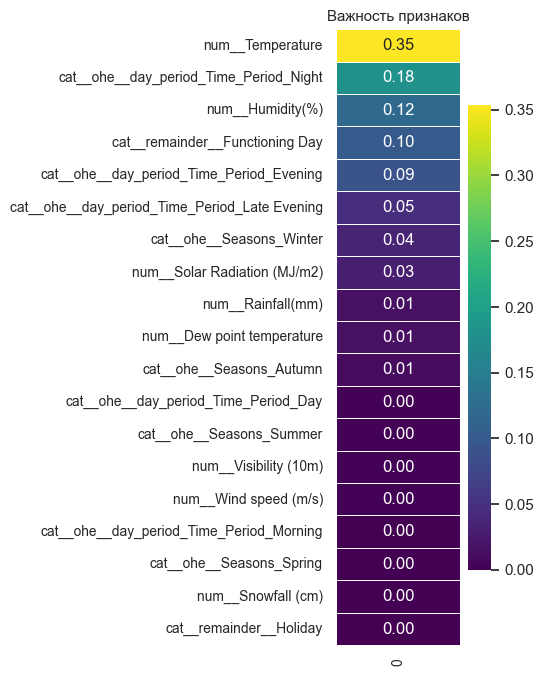

In [25]:
final_tree_pipeline.fit(X_train_full, y_train_full)
df_importances = pd.DataFrame(final_tree_pipeline.named_steps['regressor'].feature_importances_, 
                           index=final_tree_pipeline[:-1].get_feature_names_out())
draw_heatmap(df_importances.sort_values(by=0, ascending=False),
             "Важность признаков", 
             font_scale=1,
             figsize=(2, 8))

- Выведем дерево решений в текстовом виде:

In [26]:
print(export_text(final_tree_pipeline.named_steps['regressor'], 
          feature_names=final_tree_pipeline[:-1].get_feature_names_out()))

|--- num__Temperature <= 13.05
|   |--- cat__ohe__Seasons_Winter <= 0.50
|   |   |--- cat__ohe__day_period_Time_Period_Night <= 0.50
|   |   |   |--- num__Humidity(%) <= 79.50
|   |   |   |   |--- cat__remainder__Functioning Day <= 0.50
|   |   |   |   |   |--- value: [0.00]
|   |   |   |   |--- cat__remainder__Functioning Day >  0.50
|   |   |   |   |   |--- cat__ohe__Seasons_Autumn <= 0.50
|   |   |   |   |   |   |--- num__Temperature <= 7.75
|   |   |   |   |   |   |   |--- num__Solar Radiation (MJ/m2) <= 0.01
|   |   |   |   |   |   |   |   |--- value: [413.99]
|   |   |   |   |   |   |   |--- num__Solar Radiation (MJ/m2) >  0.01
|   |   |   |   |   |   |   |   |--- value: [587.15]
|   |   |   |   |   |   |--- num__Temperature >  7.75
|   |   |   |   |   |   |   |--- num__Dew point temperature <= 0.05
|   |   |   |   |   |   |   |   |--- cat__ohe__day_period_Time_Period_Day <= 0.50
|   |   |   |   |   |   |   |   |   |--- num__Solar Radiation (MJ/m2) <= 0.36
|   |   |   |   |   |  

- Самый важный признак - температура. Тёплая погода (> 13 град. C) повышает спрос на велосипеды почти в 3 раза (380 -> 1017).
- Следующие по важности признаки - сезон, время суток и влажность.
- Умеренная влажность (< 84%) при тёплой погоде дополнительно повышает спрос (1017 -> 1235)
- Самые высокие значения (~2000) - при тёплой погоде (> 20 град. C) с умеренной влажностью, вечер.
- В нерабочие дни (`Functional Day` == 0) прогноз нулевой.

### 5.2. Оценка модели на тестовой выборке

- Модель kNN на кросс-валидации показывает лучшую стабильность по стандартному отклонению, поэтому для продакшена следует выбрать ее.
- Запустим предсказание модели kNN на тестовой выборке:

In [27]:
# Обучение модели kNN и получение предсказаний
final_knn_pipeline.fit(X_train_full, y_train_full)
y_knn_pred = final_knn_pipeline.predict(X_test)
knn_test_metrics = calc_metrics(y_test, y_knn_pred)

display(knn_test_metrics)

R2       0.7574
MAE    209.6054
RMSE   315.0818
dtype: float64

- На тестировании модель показывает даже лучшие результаты, чем на кросс-валидации. Она объясняет 75.7% вариации целевой переменной. Средняя ошибка составляет 209.6 велосипедов/час, среднеквадратичное отклонение - 315.1.
- Модель показывает значительно лучшие результаты, чем линейная; её можно рекомендовать к внедрению.

## 6. Сохранение пайплайна и финальный отчёт
### 6.1. Сохранение пайплайна

In [28]:
PIPELINE_FILE_NAME = "bikesouth_knn_prediction.joblib"

try:
    # Сохраним пайплайн
    joblib.dump(final_knn_pipeline, PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка сохранения артефактов:", e)
    raise

print("Артефакты сохранены")

Артефакты сохранены


- Проверим корректность сохраненного файла:

In [29]:
try:
    predict_pipeline_loaded = joblib.load(PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка загрузки артефактов:", e)
    raise

y_pred_load = predict_pipeline_loaded.predict(X_test)

diff_pred = np.abs(y_pred_load - y_knn_pred).sum()

if diff_pred == 0.0:
    print("Пайплайн сохранен, проверка прошла успешно.")
else:
    print("Ошибка: ", diff_pred)

Пайплайн сохранен, проверка прошла успешно.


### 6.2. Финальный отчет
- Был представлен датасет в формате CSV, разделенный на обучающую и тестовую выборки, а также пайплайн с линейной моделью регресии для предсказания почасового спроса на велосипеды.
- Линейная модель была загружена и протестирована - качество её предсказаний неудовлетворительно. Линейная модель объясняет 59% дисперсии целевой переменной и ошибается в среднем на 312 велосипедов в час.
- Представленные датасеты были исследованы на предмет наличия дубликатов и пропусков. Явные дубликаты отсутствуют, пропуски есть только в числовых столбцах - они были заполнены медианой на шаге предобработки пайплайна.
- На этапе исследовательского анализа данных были исследованы распределения категориальных и числовых признаков, их корреляция друг с другом и с целевой переменной.
- Видно изменение спроса в зависимости от сезона: наименьший спрос зимой, наибольший - летом и осенью.
- В рабочие дни спрос больше, чем в выходные.
- Присутствует значительная разница в спросе в зависимости от времени дня: наибольший спрос - в вечернее время, наименьший - в ночное.
- Выбросы и аномальные значения в значениях признаков отсутствуют.
- Видна зависимость целевой переменной от погодных условий - температуры, влажности и солнечной активности. 
- Наибольший спрос наблюдается при температуре около 25 градусов и влажности около 60%
- При сильном ветре, высокой солнечной активности, осадках спрос падает.
- Целевая переменная в наибольшей степени коррелирует с периодом дня и температурой. В наименьшей степени - с количеством осадков и флагом выходного дня.
- Были обучены модели `KNeighborRegressor` и `DecisionTreeRegressor` с параметрами по умолчанию. Обе базовые модели на кросс-валидации показывают лучшие метрики, чем представленная линейная модель.
- Модель `DecisionTreeRegressor` показывает худшие результаты, чем `kNN` - видно, что она переобучается на фолдах кросс-валидации. Стабильность `DecisionTreeRegressor` с параметрами по умолчанию оказывается хуже, чем у линейной модели.
- Для моделей `KNeighborRegressor` и `DecisionTreeRegressor` был выполнен поиск оптимальных гиперпараметров с использованием библиотеки Optuna и кросс-валидации.
- Подбор гиперпараметров улучшил результаты kNN и решающего дерева: дерево сравнялось с kNN по метрикам, однако стандартное отклонение метрик по фолдам кросс-валидации у kNN оказывается меньше, чем у дерева - kNN показывает лучшую стабильность.
- Было произведено исследование значимости признаков: самый важный признак - температура. Тёплая погода (> 13 град. C) повышает спрос на велосипеды почти в 3 раза (380 -> 1017).
- Следующие по важности признаки - сезон, время суток и влажность.
- Умеренная влажность (< 84%) при тёплой погоде дополнительно повышает спрос (1017 -> 1235)
- Самые высокие значения (~2000) - при тёплой погоде (> 20 град. C) с умеренной влажностью, вечер.
- В нерабочие дни (`Functional Day` == 0) прогноз нулевой.
- На основании анализа метрик R2, MAE, RMSE и их стандартного отклонения на фолдах кросс-валидации для внедрения была выбрана улучшенная модель `KNeighborRegressor`. При тестировании модель показала хорошие результаты, пайплайн был сохранен для внедрения.
